In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

countries = ["USA", "Germany", "Poland", "Ukraine", "Canada"]
positions = ["Data Analyst", "Data Sientist", "ML Engineer", "Data Engineer"]
experiences = ["Junior", "Middle", "Senior"]
remote_options = ["Yes", "No"]

data = []

for _ in range(1000):
    country = np.random.choice(countries)
    position = np.random.choice(positions)
    experience = np.random.choice(experiences)
    remote = np.random.choice(remote_options)

    base_salary = {
        "Junior": np.random.randint(600, 2000),
        "Middle": np.random.randint(2000, 4500),
        "Senior": np.random.randint(4500, 9000)
    }[experience]
    
    country_mult = {
        "USA": 3.5,
        "Canada": 3,
        "Germany": 2.5,
        "Poland": 1.7,
        "Ukraine": 1
    }[country]

    salary = int(base_salary * country_mult)

    data.append([country, position, salary, experience, remote])

df = pd.DataFrame(data, columns=["Country", "Position", "Salary", "Experience", "Remote"])
df.to_csv("it_salary_dataset.csv", index=False)

df.head()

,Country,Position,Salary,Experience,Remote
0,Ukraine,Data Analyst,4966,Senior,Yes
1,Poland,ML Engineer,2500,Junior,No
2,Canada,Data Sientist,9645,Middle,No
3,Ukraine,Data Sientist,2474,Middle,Yes
4,Germany,Data Engineer,15997,Senior,No


In [3]:
df = pd.read_csv("it_salary_dataset.csv")

In [4]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     1000 non-null   object
 1   Position    1000 non-null   object
 2   Salary      1000 non-null   int64 
 3   Experience  1000 non-null   object
 4   Remote      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


,Salary
count,1000.000000
mean,8604.003000
std,6860.998103
min,602.000000
25%,3373.250000
50%,6207.500000
75%,12222.750000
max,31391.000000


In [5]:
salary_by_position = (
    df.groupby("Position")["Salary"]
    .mean()
    .sort_values(ascending=False)
)

print(salary_by_position)

Position
Data Engineer    9032.803704
Data Analyst     8601.367188
ML Engineer      8497.799145
Data Sientist    8227.962500
Name: Salary, dtype: float64


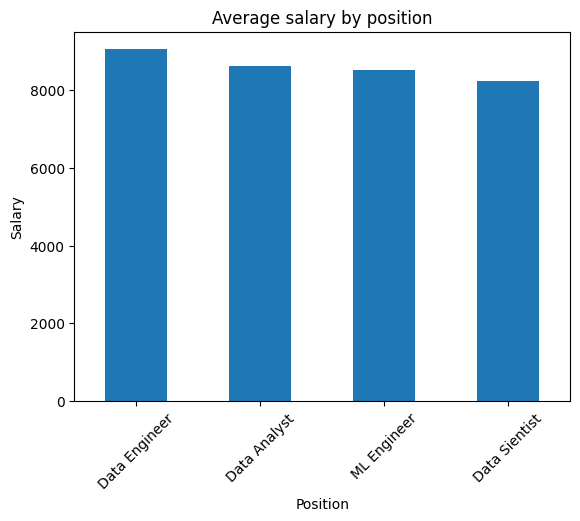

In [6]:
salary_by_position.plot(kind="bar", title="Average salary by position")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [7]:
salary_by_country = (
    df.groupby("Country")["Salary"]
    .mean()
    .sort_values(ascending=True)
)

print(salary_by_country)

Country
Ukraine     3535.619289
Poland      6054.160976
Germany     9379.149038
Canada     11529.583333
USA        12788.103448
Name: Salary, dtype: float64


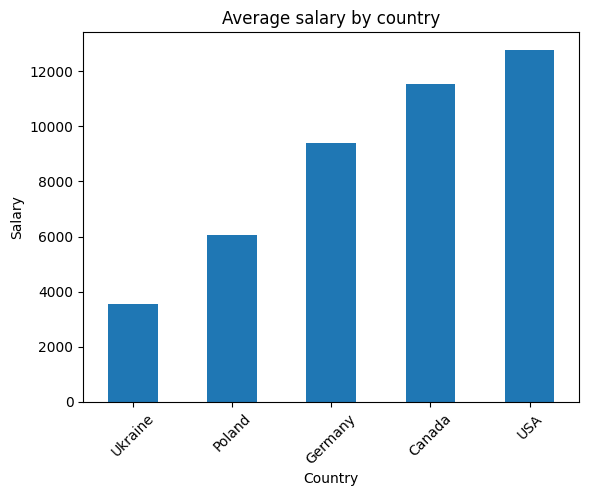

In [8]:
salary_by_country.plot(kind="bar", title="Average salary by country")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [28]:
salary_by_exp = df.groupby("Experience")["Salary"].mean()
print(salary_by_exp)

Experience
Junior     3046.157593
Middle     7566.173529
Senior    15975.546624
Name: Salary, dtype: float64


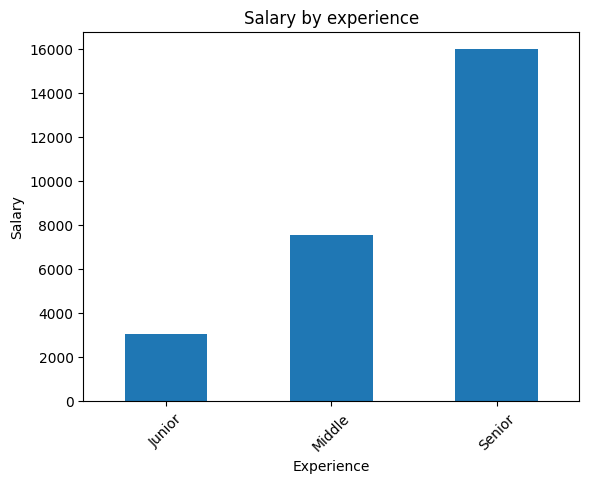

In [29]:
salary_by_exp.plot(kind="bar", title="Salary by experience")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [11]:
remote_salary = df.groupby("Remote")["Salary"].mean()
print(remote_salary)

Remote
No     8834.185547
Yes    8362.500000
Name: Salary, dtype: float64


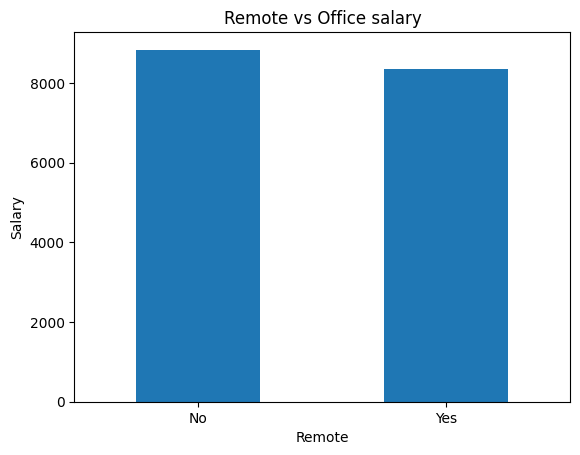

In [31]:
remote_salary.plot(kind="bar", title="Remote vs Office salary")
plt.ylabel("Salary")
plt.xticks(rotation=0)
plt.show()

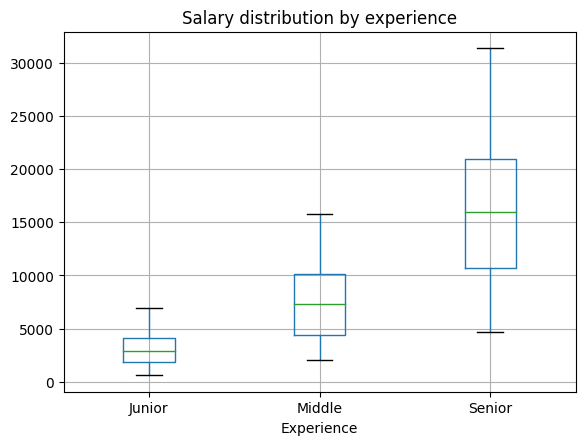

In [13]:
df.boxplot(column="Salary", by="Experience")
plt.title("Salary distribution by experience")
plt.suptitle("")
plt.show()

In [14]:
df["Salary_usd_year"] = df["Salary"] * 12
df.head()

,Country,Position,Salary,Experience,Remote,Salary_usd_year
0,Ukraine,Data Analyst,4966,Senior,Yes,59592
1,Poland,ML Engineer,2500,Junior,No,30000
2,Canada,Data Sientist,9645,Middle,No,115740
3,Ukraine,Data Sientist,2474,Middle,Yes,29688
4,Germany,Data Engineer,15997,Senior,No,191964


In [15]:
salary_usd_years = df.groupby("Position")["Salary_usd_year"].mean()
print(salary_usd_years)

Position
Data Analyst     103216.406250
Data Engineer    108393.644444
Data Sientist     98735.550000
ML Engineer      101973.589744
Name: Salary_usd_year, dtype: float64


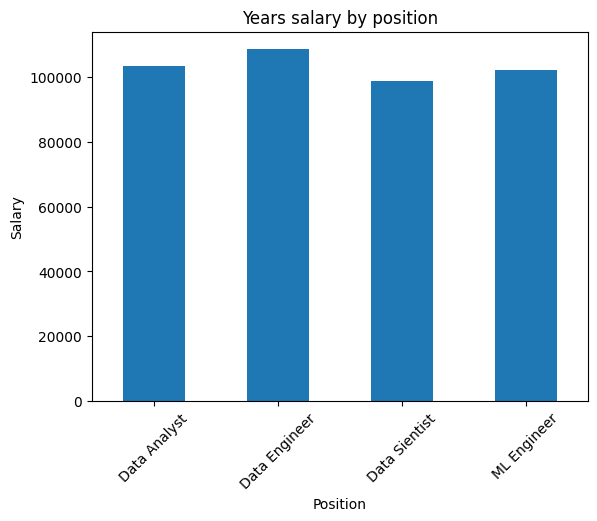

In [16]:
salary_usd_years.plot(kind="bar", title="Years salary by position")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [17]:
senior_df = df[df["Experience"] == "Senior"]
senior_mean_salary = senior_df.groupby("Country")["Salary"].mean().sort_values(ascending=False)
print(senior_mean_salary)

Country
USA        23932.203704
Canada     20577.567568
Germany    16447.538462
Poland     11322.968750
Ukraine     6658.444444
Name: Salary, dtype: float64


In [18]:
print("Top country for Senior salary:")
print(senior_mean_salary.head(1))

Top country for Senior salary:
Country
USA    23932.203704
Name: Salary, dtype: float64


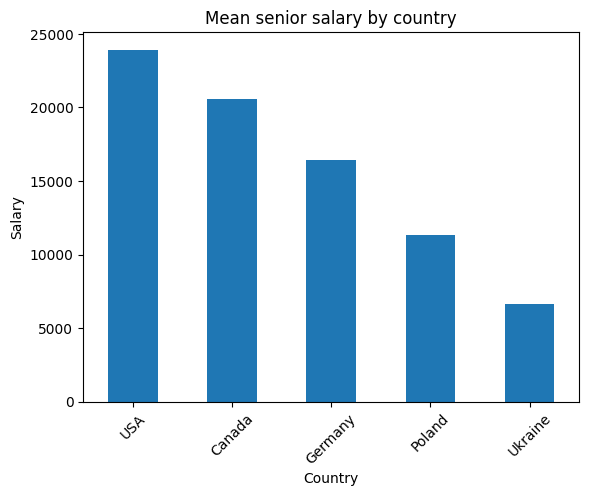

In [19]:
senior_mean_salary.plot(kind="bar", title="Mean senior salary by country")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [20]:
senior_data_scientists = senior_df[senior_df["Position"] == "Data Sientist"]
senior_ds_mean_salary = senior_data_scientists.groupby("Country")["Salary"].mean().sort_values(ascending=False)
senior_ds_mean_salary.head()

Country
USA        24947.400000
Canada     20627.250000
Germany    16900.846154
Poland     10999.071429
Ukraine     7148.916667
Name: Salary, dtype: float64

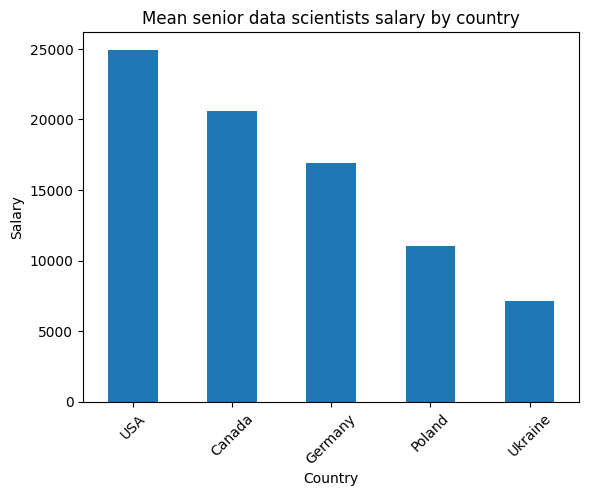

In [21]:
senior_ds_mean_salary.plot(kind="bar", title="Mean senior data scientists salary by country")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()